# Peut-on deviner où un fonds est investi en regardant seulement sa performance ?

Fonds étudié : **Fidelity Contrafund (FCNTX)**.
Références : 11 ETF sectoriels SPDR. Un ETF sectoriel sert de « règle graduée » :
si le fonds évolue comme l'ETF technologie, il a probablement beaucoup de technologie.
Le fonds ne détient pas ces ETF.

Prérequis : avoir lancé `python fetch_data.py`, qui crée `monthly_returns.csv`.

## 1. Charger les données

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

FUND = "FCNTX"
data = pd.read_csv("monthly_returns.csv", index_col=0, parse_dates=True)
y = data[FUND].values
X = data.drop(columns=FUND)
etfs = list(X.columns)
X = X.values

# Nom lisible du secteur suivi par chaque ETF (pour les tableaux et le graphique)
SECTEURS = {
    "XLK": "Tech", "XLC": "Communication", "XLF": "Finance",
    "XLY": "Conso. discrétionnaire", "XLV": "Santé", "XLI": "Industrie",
    "XLP": "Conso. de base", "XLB": "Matériaux", "XLE": "Énergie",
    "XLU": "Services publics", "XLRE": "Immobilier",
}

print(f"{len(data)} mois, de {data.index[0]:%Y-%m} à {data.index[-1]:%Y-%m}")
data.head()

98 mois, de 2018-07 à 2026-08


,FCNTX,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2018-07-31,0.019384,0.028586,-0.021603,0.015539,0.051147,0.073851,0.020872,0.039589,0.010395,0.015974,0.065540,0.018024
2018-08-31,0.045086,-0.007701,0.014858,-0.034751,0.013596,0.002340,0.065989,0.003920,0.024206,0.012881,0.043293,0.051047
2018-09-30,0.001422,-0.017954,-0.000963,0.024460,-0.022155,0.021774,-0.000192,0.009872,-0.026461,-0.006483,0.029542,0.005304
2018-10-31,-0.097232,-0.091835,-0.060408,-0.113282,-0.047135,-0.108674,-0.080048,0.020026,-0.015946,0.019753,-0.067788,-0.101006
2018-11-30,0.007075,0.038015,-0.022372,-0.015634,0.026256,0.038065,-0.019625,0.022723,0.054846,0.035388,0.080834,0.024767


## 2. Contrôle : les données sont-elles bonnes ?

On recompose les rendements mensuels en rendements annuels et on compare à ceux publiés par Fidelity.

In [2]:
publie = {2019: 29.98, 2020: 32.58, 2021: 24.36, 2022: -28.26,
          2023: 39.33, 2024: 35.97, 2025: 21.80}

annuel = (1 + data[FUND]).groupby(data.index.year).prod() - 1
controle = pd.DataFrame({
    "calculé (%)": (annuel * 100).round(2),
    "publié (%)": pd.Series(publie),
})
controle["écart"] = (controle["calculé (%)"] - controle["publié (%)"]).round(2)
controle.dropna()

,calculé (%),publié (%),écart
2019,30.00,29.98,0.02
2020,32.48,32.58,-0.10
2021,24.52,24.36,0.16
2022,-28.31,-28.26,-0.05
2023,39.37,39.33,0.04
2024,36.00,35.97,0.03
2025,21.76,21.80,-0.04


Les écarts doivent être de quelques dixièmes de point au plus. Sinon, il y a un problème de données
(devise, dividendes, dates) à régler avant de continuer.

Résultat : tous les écarts restent sous 0,2 point, les données sont utilisables.

## 3. La reconstruction

On cherche les poids `w` (positifs, somme = 100 %) tels que :

**rendement du fonds ≈ α + Σ wᵢ × rendement de l'ETF i**

`α` est un écart moyen mensuel que les ETF n'expliquent pas (frais du fonds, choix du gérant).
On cherche les poids qui rendent l'écart entre le fonds et la combinaison d'ETF le plus petit possible.

In [3]:
def reconstruire(X, y):
    n = X.shape[1]

    def erreur(p):                      # p = [w1..wn, alpha]
        w, a = p[:n], p[n]
        return np.sum((y - a - X @ w) ** 2)

    depart = np.append(np.full(n, 1 / n), 0.0)
    contraintes = {"type": "eq", "fun": lambda p: np.sum(p[:n]) - 1}
    bornes = [(0, 1)] * n + [(None, None)]
    res = minimize(erreur, depart, method="SLSQP",
                   bounds=bornes, constraints=contraintes)
    return res.x[:n], res.x[n]

w, alpha = reconstruire(X, y)
estime = pd.Series(w, index=etfs)

ajuste = alpha + X @ w
r2 = 1 - np.sum((y - ajuste) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Qualité de la ressemblance (R²) : {r2:.3f}")
print(f"α : {alpha * 12 * 100:+.2f} % par an (approx.)")
(estime * 100).round(1).sort_values(ascending=False).rename(SECTEURS).to_frame("poids estimé (%)")

Qualité de la ressemblance (R²) : 0.934
α : +0.82 % par an (approx.)


,poids estimé (%)
Tech,30.6
Communication,29.7
Santé,16.8
Conso. discrétionnaire,14.5
Industrie,8.5
Énergie,0.0
Matériaux,0.0
Conso. de base,0.0
Finance,0.0
Services publics,0.0


Le R² indique la part des variations du fonds que la combinaison d'ETF reproduit
(1 = parfaitement). Un R² élevé ne veut pas dire que chaque poids est fiable : les ETF sectoriels
se ressemblent, donc plusieurs combinaisons peuvent donner un résultat proche.

## 4. Comparaison avec les poids publiés

Source : fiche produit Fidelity Contrafund (*Fact Sheet*), tableau « Sector Diversification »,
au **30 juin 2026**. Les secteurs y suivent la classification GICS, comme les ETF SPDR Select Sector.
Les pourcentages sont saisis tels que publiés (en % de l'actif net) ; le notebook les ramène
à 100 % sur les 11 secteurs.

In [4]:
# Correspondance secteur publié -> ETF (fixée avant de regarder les résultats)
# Valeurs publiées, en % (Fidelity, fiche au 30/06/2026, secteurs GICS)
publies_bruts = {
    "XLK":  30.63,  # Information Technology
    "XLC":  22.28,  # Communication Services
    "XLF":  10.39,  # Financials
    "XLY":   9.95,  # Consumer Discretionary
    "XLV":   9.16,  # Health Care
    "XLI":   7.84,  # Industrials
    "XLP":   3.72,  # Consumer Staples
    "XLB":   1.73,  # Materials
    "XLE":   2.65,  # Energy
    "XLU":   0.03,  # Utilities
    "XLRE":  0.08,  # Real Estate
}

remplis = all(v is not None for v in publies_bruts.values())
if remplis:
    pub = pd.Series(publies_bruts).reindex(etfs).astype(float)
    pub = pub / pub.sum() * 100          # renormalisation sur les 11 secteurs
else:
    print("Poids publiés non renseignés : seuls les poids estimés seront affichés.")

In [5]:
est = estime * 100

if remplis:
    tableau = pd.DataFrame({"estimé (%)": est.round(1), "publié (%)": pub.round(1)})
    tableau["écart"] = (tableau["estimé (%)"] - tableau["publié (%)"]).round(1)
    ecart_moyen = (est - pub).abs().mean()
    ecart_naif = (100 / len(etfs) - pub).abs().mean()
    print(f"Écart absolu moyen : {ecart_moyen:.1f} points")
    print(f"Repère : {ecart_naif:.1f} points en répartissant à parts égales (1/11 par secteur)")
    display(tableau.rename(SECTEURS))
else:
    display((est.round(1)).rename(SECTEURS).to_frame("estimé (%)"))

Écart absolu moyen : 3.5 points
Repère : 7.0 points en répartissant à parts égales (1/11 par secteur)


,estimé (%),publié (%),écart
Matériaux,0.0,1.8,-1.8
Communication,29.7,22.6,7.1
Énergie,0.0,2.7,-2.7
Finance,0.0,10.6,-10.6
Industrie,8.5,8.0,0.5
Tech,30.6,31.1,-0.5
Conso. de base,0.0,3.8,-3.8
Immobilier,0.0,0.1,-0.1
Services publics,0.0,0.0,0.0
Santé,16.8,9.3,7.5


## 5. Le graphique

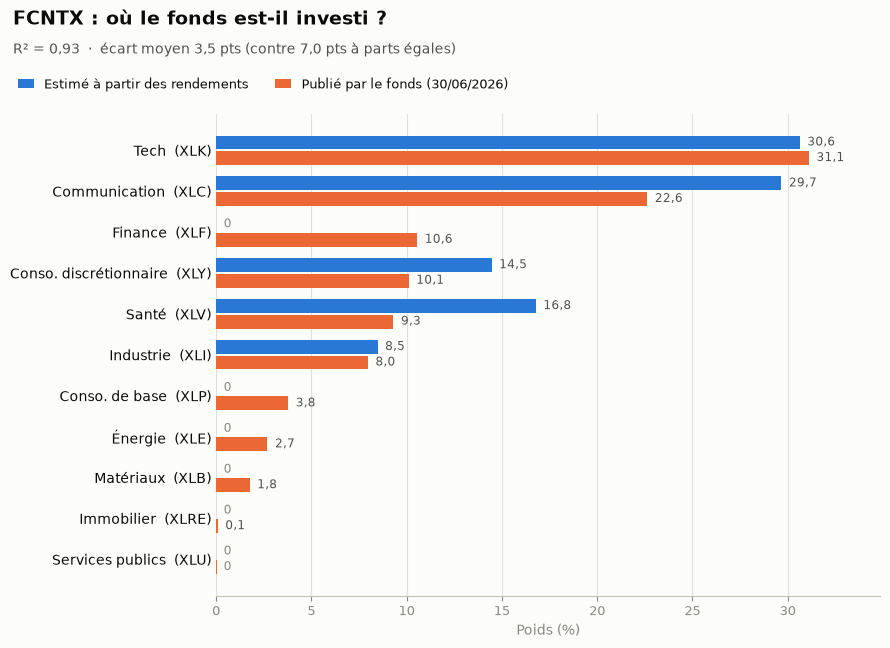

In [6]:
# Barres horizontales triées par poids publié : les noms de secteurs se lisent sans rotation.
# Deux versions (claire et sombre) pour que le README s'adapte au thème de GitHub.
THEMES = {
    "clair":  dict(fond="#fcfcfb", encre="#0b0b0b", encre2="#52514e", discret="#898781",
                   grille="#e1e0d9", axe="#c3c2b7", estime="#2a78d6", publie="#eb6834"),
    "sombre": dict(fond="#1a1a19", encre="#ffffff", encre2="#c3c2b7", discret="#898781",
                   grille="#2c2c2a", axe="#383835", estime="#3987e5", publie="#d95926"),
}

def fr(v, d=1):
    return f"{v:.{d}f}".replace(".", ",")

def graphique(t, chemin=None):
    ordre = (pub if remplis else est).sort_values().index    # plus gros secteur en haut
    yy = np.arange(len(ordre))
    h = 0.38

    fig, ax = plt.subplots(figsize=(9, 6.6), facecolor=t["fond"])
    ax.set_facecolor(t["fond"])

    series = [("Estimé à partir des rendements", est, t["estime"], +h / 2)]
    if remplis:
        series.append(("Publié par le fonds (30/06/2026)", pub, t["publie"], -h / 2))
    for nom, s, couleur, dy in series:
        v = s[ordre].values
        ax.barh(yy + dy, v, h - 0.04, color=couleur, label=nom, zorder=2)
        for yi, vi in zip(yy + dy, v):
            if vi >= 0.05:
                ax.text(vi + 0.4, yi, fr(vi), va="center", fontsize=8.5, color=t["encre2"])
            else:                                              # barre vide : on l'écrit pour qu'elle se voie
                ax.text(0.4, yi, "0", va="center", fontsize=8.5, color=t["discret"])

    ax.set_yticks(yy)
    ax.set_yticklabels([f"{SECTEURS[e]}  ({e})" for e in ordre], color=t["encre"], fontsize=10)
    ax.set_xlim(0, max(est.max(), pub.max() if remplis else 0) * 1.12)
    ax.set_xlabel("Poids (%)", color=t["discret"])
    ax.tick_params(axis="x", colors=t["discret"], labelsize=9)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color=t["grille"], linewidth=0.8, zorder=0)
    for cote in ("top", "right", "left"):
        ax.spines[cote].set_visible(False)
    ax.spines["bottom"].set_color(t["axe"])

    # Titre, sous-titre et légende alignés sur le bord gauche de la figure
    fig.text(0.02, 0.975, "FCNTX : où le fonds est-il investi ?", ha="left", va="top",
             fontsize=14, fontweight="bold", color=t["encre"])
    sous_titre = f"R² = {fr(r2, 2)}"
    if remplis:
        sous_titre += f"  ·  écart moyen {fr(ecart_moyen)} pts (contre {fr(ecart_naif)} pts à parts égales)"
    fig.text(0.02, 0.925, sous_titre, ha="left", va="top", fontsize=10, color=t["encre2"])
    leg = fig.legend(loc="upper left", bbox_to_anchor=(0.012, 0.89), ncol=2, frameon=False,
                     fontsize=9.5, handlelength=1.2)
    for texte in leg.get_texts():
        texte.set_color(t["encre"])

    fig.tight_layout(rect=(0, 0, 1, 0.84))
    if chemin:
        fig.savefig(chemin, dpi=160, facecolor=t["fond"])
    return fig

os.makedirs("figures", exist_ok=True)
graphique(THEMES["sombre"], "figures/estime_vs_publie_sombre.png")
plt.close()
graphique(THEMES["clair"], "figures/estime_vs_publie.png")
plt.show()

## 6. Lecture

- **Bien retrouvés** : la technologie (30,6 % estimé contre 31,1 % publié) et l'industrie (8,5 % contre 8,0 %).
  Le trio de tête (technologie, communication, santé/consommation) est dans le bon ordre de grandeur.
- **Manqués** : la finance (0 % estimé contre 10,6 % publié) et les petits secteurs (consommation de base,
  énergie, matériaux), mis à zéro. Leur poids est reporté sur la communication (+7,1 points), la santé (+7,5)
  et la consommation discrétionnaire (+4,4). Quand des ETF évoluent de façon proche, la méthode peut
  échanger leurs poids sans beaucoup dégrader la ressemblance. La contrainte de poids positifs pousse
  aussi les petites positions vers zéro.
- **Repère** : l'écart absolu moyen est de 3,5 points, contre 7,0 points pour une répartition à parts égales.
  La méthode fait donc deux fois mieux que le repère naïf, avec un R² de 0,93.

## Limites

- Environ 98 mois pour 11 ETF qui se ressemblent : les poids estimés sont approximatifs.
- Les deux côtés suivent la classification GICS, mais le fonds détient des titres absents des ETF
  (actions non cotées comme SpaceX, environ 9 % d'actions internationales).
- Les poids publiés sont une photo au 30 juin 2026, alors que l'estimation porte sur toute la période 2018-2026.
- Démonstration de méthode : ce n'est ni un jugement sur le fonds, ni un conseil d'investissement.